# Sistem Rekomendasi Lowongan Pekerjaan
## Hybrid TF-IDF–SBERT dengan Learning-to-Rank (LambdaMART)

Penelitian ini membangun sistem rekomendasi lowongan pekerjaan berbasis konten. Representasi teks
dibentuk dari gabungan TF-IDF dan SBERT, kemudian kandidat lowongan dirangking menggunakan metode
Learning-to-Rank (LambdaMART) dan dievaluasi menggunakan relevansi berjenjang.

Tahapan yang dilakukan:
1. Praproses teks
2. Ekstraksi fitur struktural (pengalaman, pendidikan, lokasi, gaji)
3. Pembentukan TF-IDF per-field berbobot (judul 0.50; skill 0.25; deskripsi 0.25)
4. Pembentukan representasi SBERT (768 dimensi)
5. Penggabungan representasi hybrid V = [α·TF-IDF, β·SBERT] dengan α = 0.6 dan β = 0.4
6. Penyusunan relevansi holistik berjenjang (0–4)
7. Retrieval 200 kandidat dan perangkingan dengan LambdaMART
8. Evaluasi pada beberapa nilai K

## Diagram Alir Metode

```mermaid
flowchart TD
    A["Dataset 28.858 lowongan"] --> B["Preprocessing teks"]
    B --> C1["TF-IDF per-field<br/>judul 0.50 / skill 0.25 / desk 0.25"]
    B --> C2["SBERT Transformer<br/>768-dim"]
    B --> C3["Fitur Struktural<br/>exp, edu, lokasi, gaji"]
    C1 --> D["Hybrid V = 0.6 x TFIDF + 0.4 x SBERT"]
    C2 --> D
    D --> E["TAHAP-1 Retrieval Euclidean<br/>Top-200 kandidat"]
    E --> F["Ekstraksi 10 Fitur"]
    C3 --> F
    E --> G["LABEL Relevansi Holistik 0-4"]
    F --> H["TAHAP-2 LambdaMART<br/>optimasi NDCG"]
    G --> H
    H --> I(["OUTPUT Top-K rekomendasi"])
```


In [ ]:
# === 0. Import & Konfigurasi ===
from pathlib import Path
import re, time, warnings
import numpy as np, pandas as pd, joblib
from scipy.sparse import hstack as sparse_hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
import lightgbm as lgb
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from IPython.display import display
import torch
warnings.filterwarnings("ignore")

SEED = 42; np.random.seed(SEED); torch.manual_seed(SEED)
# The find_base function is no longer needed as the CSV path is now directly specified from Google Drive.
CSV = Path('/content/drive/MyDrive/JobPostings/JobPosting.csv')
BASE = CSV.parent # Set BASE to the directory containing the CSV, i.e., '/content/drive/MyDrive/JobPostings'

# Hyperparameter
TFIDF_TITLE, TFIDF_SKILLS, TFIDF_DESC = 2000, 2000, 1000
W_TITLE, W_SKILLS, W_DESC = 0.50, 0.25, 0.25
SBERT_MODEL = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
SBERT_BATCH = 64
ALPHA, BETA = 0.6, 0.4
POOL = 200; K_LIST = [5, 10, 20, 30]; TEST_FRAC = 0.30

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# After mounting, update the 'CSV' variable in the 'Import & Konfigurasi' cell (31bdc3b2)
# with the actual path to your JobPosting.csv file on Google Drive.
# For example:
# CSV = Path('/content/drive/MyDrive/Dataset/JobPosting.csv')

Mounted at /content/drive


## 1. Praproses Dataset

Teks dibersihkan (huruf kecil, penghapusan URL dan karakter non-alfanumerik), data duplikat dihapus,
dan field judul, skill, serta deskripsi digabung menjadi satu teks untuk SBERT.

In [ ]:
def clean_text(value):
    if pd.isna(value): return ""
    text = str(value).lower()
    text = re.sub(r"http\S+|www\S+|\S+@\S+", " ", text)
    text = re.sub(r"[^a-z0-9+#.\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()
def combine_job_text(row):
    return clean_text(" ".join([str(row.get("job_title","") or ""),
                                str(row.get("skills","") or ""),
                                str(row.get("job_description","") or "")]))

raw_df = pd.read_csv(CSV, encoding="utf-8", on_bad_lines="skip")
req = ["job_title","skills","job_description","location","education_level",
       "experience_level","salary","company_industry","career_level"]
for c in req:
    if c not in raw_df.columns: raw_df[c] = np.nan
df = raw_df.copy()
text_columns = ["job_title","skills","job_description","location",
                "education_level","experience_level","company_industry","career_level"]
df[text_columns] = df[text_columns].fillna("")
df = df.drop_duplicates(subset=["job_title","company_industry","location"], keep="first").reset_index(drop=True)
df["hybrid_text"] = df.apply(combine_job_text, axis=1)
df["title_clean"]  = df["job_title"].apply(clean_text)
df["skills_clean"] = df["skills"].apply(clean_text)
df["desc_clean"]   = df["job_description"].apply(clean_text)
df = df[df["hybrid_text"].str.len() > 0].reset_index(drop=True)
print(f"Data eksperimen: {len(df):,} lowongan")
display(df[["job_title","skills","location","hybrid_text"]].head(3))

Data eksperimen: 28,858 lowongan


,job_title,skills,location,hybrid_text
0,Facility Maintenance & Smart Warehouse Manager,"Communication, English, K3, KPI, Leadership, M...",Bandung,facility maintenance smart warehouse manager c...
1,Procurement Department Head,"Database, English, Negotiation",Jakarta Raya,procurement department head database english n...
2,SALES ADMIN,"API, Communication, English, Excel, Microsoft ...",Jakarta Barat,sales admin api communication english excel mi...


## 2. Fitur Struktural (pengalaman, pendidikan, lokasi, gaji)

In [ ]:
MAX_EXP = 10.0
def experience_years(v):
    t = clean_text(v)
    if not t: return np.nan
    if "fresh" in t: return 0.0
    n = re.findall(r"\d+(?:[.,]\d+)?", t)
    return min(float(n[0].replace(",", ".")), MAX_EXP) if n else np.nan
def education_value(v):
    t = str(v).upper() if not pd.isna(v) else ""
    if not t or "TIDAK TERSPESIFIKASI" in t: return np.nan
    m = {"SMA":0.0,"SMU":0.0,"SMK":0.0,"STM":0.0,"D3":0.25,"D4":0.40,"S1":0.50,
         "SARJANA":0.50,"S2":0.75,"MAGISTER":0.75,"S3":1.0,"DOKTOR":1.0}
    f = [s for l,s in m.items() if l in t]; return min(f) if f else np.nan
def location_value(v):
    t = clean_text(v); a = {"jakarta raya":"jakarta","dki jakarta":"jakarta"}; return a.get(t, t)
df["exp_norm"] = df["experience_level"].map(experience_years)/MAX_EXP
df["edu_norm"] = df["education_level"].map(education_value)
df["loc_norm"] = df["location"].map(location_value)
df["salary_numeric"] = pd.to_numeric(df["salary"], errors="coerce")
vs = df.loc[df["salary_numeric"]>0,"salary_numeric"]; smin=vs.min() if len(vs) else 0.0; smax=vs.max() if len(vs) else 1.0
df["salary_norm"] = ((df["salary_numeric"]-smin)/max(smax-smin,1)).clip(0,1)
exp_arr=df["exp_norm"].to_numpy(); edu_arr=df["edu_norm"].to_numpy()
sal_arr=df["salary_norm"].to_numpy(); loc_arr=df["loc_norm"].to_numpy()
print("Ketersediaan (%):", df[["exp_norm","edu_norm","salary_norm"]].notna().mean().mul(100).round(1).to_dict())

Ketersediaan (%): {'exp_norm': 86.8, 'edu_norm': 82.1, 'salary_norm': 26.4}


## 3. Kategori dan Himpunan Skill

Kategori judul dan himpunan skill digunakan untuk menyusun relevansi pada tahap evaluasi.
Keduanya tidak dijadikan fitur model agar tidak terjadi kebocoran label.

In [ ]:
TITLE_CATEGORIES = {
 "Data Analytics":["data analyst","business intelligence","bi analyst","reporting analyst","analytics"],
 "Data Science and AI":["data scientist","machine learning","ml engineer","artificial intelligence","ai engineer"],
 "Data Engineering":["data engineer","etl developer","database engineer","database administrator","big data"],
 "Software Development":["software","developer","programmer","backend","front end","frontend","full stack","mobile developer","web developer"],
 "IT Infrastructure and Security":["network","system administrator","infrastructure","cloud","cyber security","cybersecurity","information security","devops"],
 "UI UX and Product":["ui ux","ux designer","ui designer","product designer","product manager","product owner"],
 "Sales and Business Development":["sales","account executive","business development","relationship manager","telesales"],
 "Finance and Accounting":["finance","accounting","accountant","tax","audit","treasury","financial analyst"],
 "Human Resources":["human resource","human capital","recruiter","talent acquisition","people development","payroll"],
 "Marketing and Communication":["marketing","digital marketing","brand","social media","content writer","public relation","communication"],
 "Administration and Operations":["administration","administrative","operator","operations","office staff","customer service","procurement","warehouse"],
 "Engineering":["engineer","engineering","mechanical","electrical","civil","quality assurance","quality control","technician"]}
def title_category(t):
    t=clean_text(t)
    for cat,kws in TITLE_CATEGORIES.items():
        if any(k in t for k in kws): return cat
    return "Other"
df["title_category"]=df["job_title"].map(title_category); cat_arr=df["title_category"].to_numpy()
def skill_token_set(v):
    t=clean_text(v); stop={"and","or","with","using","skill","skills","ability","knowledge","experience","good","strong","basic"}
    return {x for x in t.split() if len(x)>1 and x not in stop}
skills=df["skills"].map(skill_token_set).tolist()
print(df["title_category"].value_counts().head(8).to_string())

title_category
Other                             15713
Sales and Business Development     4242
Finance and Accounting             2297
Marketing and Communication        2204
Software Development               1308
Engineering                        1238
Administration and Operations       974
Human Resources                     273


## 4. Representasi TF-IDF

TF-IDF dihitung terpisah untuk judul, skill, dan deskripsi. Setiap bagian diberi bobot (judul 0.50,
skill 0.25, deskripsi 0.25), digabung, lalu dinormalisasi L2. Representasi ini menekankan kecocokan
kata kunci secara leksikal.

In [ ]:
t0 = time.time()
vec_title = TfidfVectorizer(max_features=TFIDF_TITLE, ngram_range=(1,3), min_df=2, max_df=0.8, sublinear_tf=True, norm="l2")
vec_skills= TfidfVectorizer(max_features=TFIDF_SKILLS,ngram_range=(1,3), min_df=2, max_df=0.8, sublinear_tf=True, norm="l2")
vec_desc  = TfidfVectorizer(max_features=TFIDF_DESC,  ngram_range=(1,2), min_df=2, max_df=0.8, sublinear_tf=True, norm="l2")
m_title  = vec_title.fit_transform(df["title_clean"]).multiply(W_TITLE)
m_skills = vec_skills.fit_transform(df["skills_clean"]).multiply(W_SKILLS)
m_desc   = vec_desc.fit_transform(df["desc_clean"]).multiply(W_DESC)
tfidf_norm = normalize(sparse_hstack([m_title, m_skills, m_desc]).tocsr(), norm="l2").toarray().astype("float32")
print(f"TF-IDF selesai: {tfidf_norm.shape} dalam {time.time()-t0:.1f}s")

TF-IDF selesai: (28858, 5000) dalam 10.8s


## 5. Representasi SBERT

SBERT (Sentence-BERT) menghasilkan embedding 768 dimensi yang merepresentasikan makna semantik teks.
Proses encoding dijalankan pada GPU (CUDA). Parameter `USE_SBERT_CACHE` menentukan apakah embedding
dihitung ulang atau dimuat dari berkas; pada konfigurasi ini embedding dihitung penuh dan disimpan ke
`notebook_artifacts/sbert_fresh_full.joblib`.

In [ ]:
from sentence_transformers import SentenceTransformer
sbert_model = SentenceTransformer(SBERT_MODEL)
print("Device model SBERT:", sbert_model)
t0 = time.time()
sbert_dense = sbert_model.encode(
    df["hybrid_text"].tolist(), batch_size=SBERT_BATCH,
    show_progress_bar=True, convert_to_numpy=True).astype("float32")
sbert_norm = normalize(sbert_dense, norm="l2").astype("float32")
print(f"SBERT selesai dalam {(time.time()-t0)/60:.2f} menit | shape {sbert_norm.shape}")
assert sbert_norm.shape[0] == len(df), "Baris SBERT tidak cocok"
assert sbert_norm.shape[1] == 768

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Device model SBERT: SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'XLMRobertaModel'})
  (1): Pooling({'embedding_dimension': 768, 'pooling_mode': 'mean', 'include_prompt': True})
)


Batches:   0%|          | 0/451 [00:00<?, ?it/s]

SBERT selesai dalam 3.48 menit | shape (28858, 768)


## 6. Representasi Hybrid

Representasi hybrid menggabungkan TF-IDF (leksikal) dan SBERT (semantik):
V = [α·TF-IDF, β·SBERT] dengan α = 0.6 dan β = 0.4, kemudian dinormalisasi.

In [ ]:
hybrid_matrix = np.concatenate([ALPHA*tfidf_norm, BETA*sbert_norm], axis=1).astype("float32")
Hsq = (hybrid_matrix*hybrid_matrix).sum(axis=1)
summary = pd.DataFrame({"cabang":["TF-IDF","SBERT","Hybrid"],
                        "dimensi":[tfidf_norm.shape[1], sbert_norm.shape[1], hybrid_matrix.shape[1]],
                        "bobot":[ALPHA, BETA, 1.0]})
display(summary)
print("Hybrid:", hybrid_matrix.shape)

,cabang,dimensi,bobot
0,TF-IDF,5000,0.6
1,SBERT,768,0.4
2,Hybrid,5768,1.0


Hybrid: (28858, 5768)


## 7. Relevansi Holistik

Relevansi setiap kandidat dihitung sebagai kombinasi berbobot dari kesamaan kategori, kemiripan skill,
serta kedekatan pengalaman, pendidikan, dan lokasi, kemudian didiskretkan menjadi tingkat 0–4.

$$\text{rel}=0.40\,\text{kategori}+0.25\,\text{skill}_{Jaccard}+0.15\,\text{exp}+0.10\,\text{edu}+0.10\,\text{lokasi}$$

In [ ]:
W_CAT,W_SK,W_EX,W_ED,W_LO = 0.40,0.25,0.15,0.10,0.10
def jaccard(a,b):
    if not a or not b: return 0.0
    u=len(a|b); return len(a&b)/u if u else 0.0
def vec_fit(arr,qi,pool):
    a=arr[qi]; b=arr[pool]
    if np.isnan(a): return np.zeros(len(pool),dtype=np.float32)
    return np.where(~np.isnan(b),1.0-np.abs(b-a),0.0).astype(np.float32)
def holistic_relevance(qi,pool):
    cat=(cat_arr[pool]==cat_arr[qi]).astype(np.float32)
    qs=skills[qi]; sk=np.array([jaccard(qs,skills[int(j)]) for j in pool],dtype=np.float32)
    ex=vec_fit(exp_arr,qi,pool); ed=vec_fit(edu_arr,qi,pool)
    lo=np.array([1.0 if (loc_arr[qi] and loc_arr[int(j)] and loc_arr[qi]==loc_arr[int(j)]) else 0.0 for j in pool],dtype=np.float32)
    return W_CAT*cat+W_SK*sk+W_EX*ex+W_ED*ed+W_LO*lo
def to_graded(rel): return np.digitize(rel, np.array([0.15,0.30,0.45,0.60]))

## 8. Retrieval Kandidat dan Ekstraksi Fitur

Untuk setiap query diambil 200 kandidat terdekat berdasarkan jarak Euclidean pada representasi hybrid.
Tiap kandidat dideskripsikan oleh sepuluh fitur: kemiripan teks (hybrid, TF-IDF, SBERT) dan kecocokan
struktural (lokasi, pendidikan, pengalaman, gaji). Kategori dan skill tidak digunakan sebagai fitur
karena keduanya merupakan komponen label relevansi.

In [ ]:
FEAT = ["sim_hybrid","sim_tfidf","sim_sbert","loc_match","edu_fit","edu_av","exp_fit","exp_av","sal_fit","sal_av"]
vc = df["title_category"].value_counts()
elig = df.index[(df["title_category"]!="Other") & (df["title_category"].map(vc) > max(K_LIST))].to_numpy()
rng = np.random.default_rng(SEED); rng.shuffle(elig)
print(f"Query memenuhi syarat (diproses semua): {len(elig):,}")

def vec_fit_av(arr,qi,pool):
    a=arr[qi]; b=arr[pool]
    if np.isnan(a): return np.zeros(len(pool),dtype=np.float32), np.zeros(len(pool),dtype=np.float32)
    return (np.where(~np.isnan(b),1.0-np.abs(b-a),0.0).astype(np.float32),
            (~np.isnan(b)).astype(np.float32))

all_pool, all_X, all_graded = [], [], []
CH=256; t0=time.time()
for s in range(0,len(elig),CH):
    qc=elig[s:s+CH]; Qv=hybrid_matrix[qc]
    G=hybrid_matrix@Qv.T; d2=Hsq[:,None]+Hsq[qc][None,:]-2.0*G
    for k,qi in enumerate(qc):
        col=d2[:,k]; col[qi]=np.inf
        cand=np.argpartition(col,POOL)[:POOL]; cand=cand[np.argsort(col[cand])]
        sim_hy=(1.0/(1.0+np.sqrt(np.clip(col[cand],0,None)))).astype(np.float32)
        sim_tf=np.asarray(tfidf_norm[cand]@tfidf_norm[qi]).ravel().astype(np.float32)
        sim_sb=(sbert_norm[cand]@sbert_norm[qi]).astype(np.float32)
        lo=np.array([1.0 if (loc_arr[qi] and loc_arr[int(j)] and loc_arr[qi]==loc_arr[int(j)]) else 0.0 for j in cand],dtype=np.float32)
        ef,ea=vec_fit_av(edu_arr,qi,cand); xf,xa=vec_fit_av(exp_arr,qi,cand); sf,sa=vec_fit_av(sal_arr,qi,cand)
        X=np.stack([sim_hy,sim_tf,sim_sb,lo,ef,ea,xf,xa,sf,sa],axis=1).astype(np.float32)
        all_pool.append(cand); all_X.append(X); all_graded.append(to_graded(holistic_relevance(qi,cand)))
    if (s//CH)%10==0: print(f"  {s+len(qc):,}/{len(elig):,} | {time.time()-t0:.0f}s", flush=True)
print(f"Ekstraksi selesai: {time.time()-t0:.0f}s | total query: {len(all_X):,}")

Query memenuhi syarat (diproses semua): 13,116
  256/13,116 | 1s
  2,816/13,116 | 18s
  5,376/13,116 | 33s
  7,936/13,116 | 49s
  10,496/13,116 | 65s
  13,056/13,116 | 81s
Ekstraksi selesai: 82s | total query: 13,116


## 9. Pembagian Data dan Pelatihan LambdaMART

Query dibagi menjadi data latih dan data uji (pembagian dilakukan per query). LambdaMART dilatih untuk
mempelajari fungsi skor perangkingan yang mengoptimalkan NDCG.

In [ ]:
n=len(all_X); n_test=int(n*TEST_FRAC); idx=np.arange(n); rng.shuffle(idx)
test_set=set(idx[:n_test].tolist())
train_pos=[i for i in range(n) if i not in test_set]; test_pos=[i for i in range(n) if i in test_set]
Xtr=np.vstack([all_X[i] for i in train_pos]); ytr=np.concatenate([all_graded[i] for i in train_pos])
grp=[len(all_graded[i]) for i in train_pos]
print(f"Train: {len(train_pos):,} query ({len(ytr):,} baris) | Test: {len(test_pos):,} query")
t0=time.time()
ranker=lgb.LGBMRanker(objective="lambdarank",metric="ndcg",n_estimators=500,learning_rate=0.05,
    num_leaves=63,min_child_samples=30,subsample=0.9,colsample_bytree=0.9,random_state=SEED,verbose=-1)
ranker.fit(Xtr,ytr,group=grp)
print(f"LambdaMART dilatih: {time.time()-t0:.0f}s")

Train: 9,182 query (1,836,400 baris) | Test: 3,934 query
LambdaMART dilatih: 351s


## 10. Evaluasi Metode (multi-K)

In [ ]:
def dcg(g,k): disc=1/np.log2(np.arange(2,k+2)); return float(np.sum(g[:k]*disc))
def ndcg_graded(order,graded,k):
    g=2.0**graded[order[:k]]-1; ideal=2.0**np.sort(graded)[::-1][:k]-1
    iz=dcg(ideal,k); return dcg(g,k)/iz if iz else 0.0
def precision_at(order,high,k): return float(high[order[:k]].mean())
def ap_at(order,high,k):
    rel=high[order[:k]]
    if rel.sum()==0: return 0.0
    cum=np.cumsum(rel); pos=cum/np.arange(1,k+1); return float((pos*rel).sum()/min(int(high.sum()),k))
ndcg_at={k:[] for k in K_LIST}; prec_at={k:[] for k in K_LIST}; map_at={k:[] for k in K_LIST}
for i in test_pos:
    X=all_X[i]; graded=all_graded[i]; order=np.argsort(-ranker.predict(X)); high=(graded>=2).astype(int)
    for k in K_LIST:
        ndcg_at[k].append(ndcg_graded(order,graded,k)); prec_at[k].append(precision_at(order,high,k)); map_at[k].append(ap_at(order,high,k))
print("="*52); print("KINERJA METODE USULAN (Holistic, query uji) — multi-K"); print("="*52)
print(f"{'K':>4} | {'NDCG':>8} | {'Precision':>10} | {'MAP':>8}"); print("-"*40)
for k in K_LIST:
    print(f"{k:>4} | {np.mean(ndcg_at[k])*100:>7.2f}% | {np.mean(prec_at[k])*100:>9.2f}% | {np.mean(map_at[k])*100:>7.2f}%")

KINERJA METODE USULAN (Holistic, query uji) — multi-K
   K |     NDCG |  Precision |      MAP
----------------------------------------
   5 |   87.42% |     90.50% |   88.25%
  10 |   86.29% |     89.27% |   85.78%
  20 |   85.03% |     87.98% |   83.28%
  30 |   84.24% |     86.99% |   81.62%


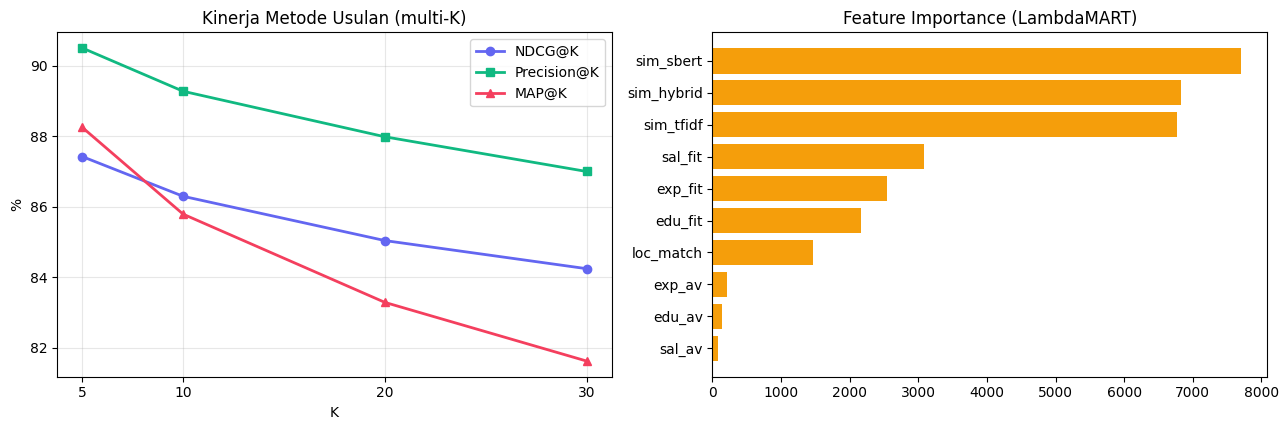

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(13,4.4)); ks=K_LIST
ax[0].plot(ks,[np.mean(ndcg_at[k])*100 for k in ks],"o-",color="#6366f1",lw=2,label="NDCG@K")
ax[0].plot(ks,[np.mean(prec_at[k])*100 for k in ks],"s-",color="#10b981",lw=2,label="Precision@K")
ax[0].plot(ks,[np.mean(map_at[k])*100 for k in ks],"^-",color="#f43f5e",lw=2,label="MAP@K")
ax[0].set_title("Kinerja Metode Usulan (multi-K)"); ax[0].set_xlabel("K"); ax[0].set_ylabel("%")
ax[0].set_xticks(ks); ax[0].legend(); ax[0].grid(alpha=.3)
imp=sorted(zip(FEAT,ranker.feature_importances_),key=lambda z:z[1])
ax[1].barh([f for f,_ in imp],[v for _,v in imp],color="#f59e0b"); ax[1].set_title("Feature Importance (LambdaMART)")
plt.tight_layout(); plt.show()

## 10b. Studi Ablation dan Pembanding

Bagian ini membandingkan kontribusi tiap komponen pada **ground truth holistik yang sama** dan query uji yang sama.
TF-IDF saja, SBERT saja, dan Hybrid menggunakan kemiripan langsung (tanpa pembelajaran); "fusi tetap" memakai
rata-rata seluruh fitur (bobot tetap); metode usulan memakai LambdaMART (bobot dipelajari). Uji Wilcoxon menilai
signifikansi perbedaan NDCG@10 antara metode usulan dan tiap baseline.

In [ ]:
# Ablation: bandingkan komponen pada ground truth holistik yang sama
methods_abl = {
    "TF-IDF saja":         lambda X: X[:, 1],        # sim_tfidf
    "SBERT saja":          lambda X: X[:, 2],        # sim_sbert
    "Hybrid (tanpa LTR)":  lambda X: X[:, 0],        # sim_hybrid
    "Hybrid + fusi tetap": lambda X: X.mean(axis=1), # rata-rata fitur (bobot tetap)
    "Hybrid + LambdaMART": lambda X: ranker.predict(X),
}
abl = {m: {"nd": {k: [] for k in K_LIST}, "pr": {k: [] for k in K_LIST},
           "mp": {k: [] for k in K_LIST}} for m in methods_abl}
for i in test_pos:
    X = all_X[i]; graded = all_graded[i]; high = (graded >= 2).astype(int)
    for m, fn in methods_abl.items():
        order = np.argsort(-fn(X))
        for k in K_LIST:
            abl[m]["nd"][k].append(ndcg_graded(order, graded, k))
            abl[m]["pr"][k].append(precision_at(order, high, k))
            abl[m]["mp"][k].append(ap_at(order, high, k))

tabel = pd.DataFrame({
    "Metode":       list(methods_abl),
    "NDCG@10":      [round(np.mean(abl[m]["nd"][10])*100, 2) for m in methods_abl],
    "Precision@10": [round(np.mean(abl[m]["pr"][10])*100, 2) for m in methods_abl],
    "MAP@10":       [round(np.mean(abl[m]["mp"][10])*100, 2) for m in methods_abl],
    "NDCG@5":       [round(np.mean(abl[m]["nd"][5])*100, 2) for m in methods_abl],
    "NDCG@20":      [round(np.mean(abl[m]["nd"][20])*100, 2) for m in methods_abl],
})
display(tabel)

print("Uji Wilcoxon (NDCG@10) - Hybrid + LambdaMART vs tiap baseline:")
prop = abl["Hybrid + LambdaMART"]["nd"][10]
for m in methods_abl:
    if m == "Hybrid + LambdaMART":
        continue
    stat, pv = wilcoxon(prop, abl[m]["nd"][10])
    unggul = "LambdaMART unggul" if np.mean(prop) > np.mean(abl[m]["nd"][10]) else "baseline unggul"
    print(f"  vs {m:<22}: p = {pv:.3g}  ({unggul})")

,Metode,NDCG@10,Precision@10,MAP@10,NDCG@5,NDCG@20
0,TF-IDF saja,70.93,86.94,84.20,72.40,69.65
1,SBERT saja,69.00,83.72,78.07,70.12,68.27
2,Hybrid (tanpa LTR),73.00,88.55,85.89,74.70,71.71
3,Hybrid + fusi tetap,80.57,91.51,89.01,81.52,79.56
4,Hybrid + LambdaMART,86.29,89.27,85.78,87.42,85.03


Uji Wilcoxon (NDCG@10) - Hybrid + LambdaMART vs tiap baseline:
  vs TF-IDF saja           : p = 0  (LambdaMART unggul)
  vs SBERT saja            : p = 0  (LambdaMART unggul)
  vs Hybrid (tanpa LTR)    : p = 0  (LambdaMART unggul)
  vs Hybrid + fusi tetap   : p = 7.54e-131  (LambdaMART unggul)


## 11. Contoh Masukan dan Keluaran

Satu lowongan dari data uji digunakan sebagai contoh masukan, lalu ditampilkan sepuluh rekomendasi
teratas beserta tingkat relevansi dan skor perangkingan.

In [ ]:
t=test_pos[0]; q_idx=int(elig[t]); pool=all_pool[t]; X=all_X[t]; graded=all_graded[t]
scores=ranker.predict(X); order=np.argsort(-scores); topk=pool[order[:10]]
print("="*60); print("INPUT  — Lowongan Query"); print("="*60)
print("Judul   :", df.at[q_idx,"job_title"]); print("Skill   :", (df.at[q_idx,"skills"][:90] or "-"))
print("Lokasi  :", (df.at[q_idx,"location"] or "-")); print("Kategori:", df.at[q_idx,"title_category"])
print("\n"+"="*60); print("OUTPUT — Top-10 Rekomendasi (oleh LambdaMART)"); print("="*60)
out=df.loc[topk,["job_title","location","title_category"]].copy(); out.insert(0,"rank",range(1,len(out)+1))
out["relevansi(0-4)"]=graded[order[:10]]; out["skor_LTR"]=np.round(np.sort(scores)[::-1][:10],3)
out=out.rename(columns={"job_title":"Judul Lowongan","location":"Lokasi","title_category":"Kategori"})
display(out.reset_index(drop=True))

INPUT  — Lowongan Query
Judul   : Staff Accounting/Finance
Skill   : Excel, Leadership, Microsoft Excel, Spreadsheet
Lokasi  : Jakarta Selatan
Kategori: Finance and Accounting

OUTPUT — Top-10 Rekomendasi (oleh LambdaMART)


,rank,Judul Lowongan,Lokasi,Kategori,relevansi(0-4),skor_LTR
0,1,Staff Accounting/ Finance,Jakarta Selatan,Finance and Accounting,3,0.025
1,2,Staff accounting,Jakarta Selatan,Finance and Accounting,3,-0.602
2,3,Staff Accounting,Jakarta Selatan,Finance and Accounting,3,-0.653
3,4,Accounting & Finance Coordinator,Jakarta Selatan,Finance and Accounting,3,-1.058
4,5,Staff Accounting,Jakarta Raya,Finance and Accounting,3,-1.110
5,6,Staff Accounting & Finance,Jakarta Selatan,Finance and Accounting,3,-1.264
6,7,Staff Accounting,Jakarta Selatan,Finance and Accounting,3,-1.294
7,8,Staff Accounting Pajak,Jakarta Selatan,Finance and Accounting,3,-1.309
8,9,"Accounting, Finance, Administration",Jakarta Selatan,Finance and Accounting,3,-1.333
9,10,Staff Accounting,Bandung,Finance and Accounting,2,-1.388


## 12. Kesimpulan

Penelitian ini menggabungkan representasi TF-IDF dan SBERT, menyusun relevansi holistik, dan menerapkan
LambdaMART untuk perangkingan kandidat lowongan. Representasi hybrid memadukan kecocokan leksikal
(TF-IDF) dan semantik (SBERT), sedangkan LambdaMART mempelajari bobot tiap kriteria dengan mengoptimalkan
NDCG. Evaluasi dilakukan pada beberapa nilai K.

Pengembangan selanjutnya mencakup penambahan metode pembanding pada ground truth yang sama beserta uji
signifikansi, serta validasi relevansi melalui anotasi manusia.

Nilai SEED = 42 digunakan agar hasil konsisten antar-eksekusi.

## 13. Pengujian dengan Masukan Dinamis (Interaktif)

Sel berikut meminta profil pencari kerja melalui `input()` (posisi, skill, pengalaman, lokasi), lalu menampilkan rekomendasi lowongan dari model LambdaMART yang telah dilatih.

> Jalankan sel ini secara interaktif (mode notebook biasa). Saat dijalankan, kotak input akan muncul untuk diisi. Tidak cocok dijalankan via *Run All* non-interaktif.

In [ ]:
# Fungsi rekomendasi untuk masukan baru
from scipy.sparse import hstack as _hstack

def recommend_for(title, skills, description="", experience="", education="",
                  location="", salary=np.nan, top_k=10):
    # 1) Representasi teks query: TF-IDF per-field + SBERT -> hybrid
    t = vec_title.transform([clean_text(title)]).multiply(W_TITLE)
    s = vec_skills.transform([clean_text(skills)]).multiply(W_SKILLS)
    d = vec_desc.transform([clean_text(description)]).multiply(W_DESC)
    tfidf_u = normalize(_hstack([t, s, d]).tocsr(), norm="l2").toarray().astype("float32").ravel()
    sbert_txt = clean_text(" ".join([title, skills, description]))
    sbert_u = normalize(sbert_model.encode([sbert_txt], convert_to_numpy=True), norm="l2").astype("float32").ravel()
    hybrid_u = np.concatenate([ALPHA*tfidf_u, BETA*sbert_u]).astype("float32")

    # 2) Retrieval Top-200 (jarak Euclidean)
    d2 = Hsq + float((hybrid_u*hybrid_u).sum()) - 2.0*(hybrid_matrix @ hybrid_u)
    pool = np.argpartition(d2, POOL)[:POOL]; pool = pool[np.argsort(d2[pool])]
    sim_hy = (1.0/(1.0+np.sqrt(np.clip(d2[pool], 0, None)))).astype(np.float32)
    sim_tf = (tfidf_norm[pool] @ tfidf_u).astype(np.float32)
    sim_sb = (sbert_norm[pool] @ sbert_u).astype(np.float32)

    # 3) Fitur struktural query
    qe = experience_years(experience); q_exp = qe/MAX_EXP if not np.isnan(qe) else np.nan
    q_edu = education_value(education); q_loc = location_value(location)
    q_sal = ((salary - smin)/max(smax-smin, 1)) if (salary == salary and salary > 0) else np.nan
    def fit_scalar(qval, arr):
        if np.isnan(qval): return np.zeros(len(pool), np.float32), np.zeros(len(pool), np.float32)
        b = arr[pool]
        return (np.where(~np.isnan(b), 1.0-np.abs(b-qval), 0.0).astype(np.float32),
                (~np.isnan(b)).astype(np.float32))
    lo = np.array([1.0 if (q_loc and loc_arr[int(j)] and q_loc == loc_arr[int(j)]) else 0.0 for j in pool], np.float32)
    ef, ea = fit_scalar(q_edu, edu_arr); xf, xa = fit_scalar(q_exp, exp_arr); sf, sa = fit_scalar(q_sal, sal_arr)
    X = np.stack([sim_hy, sim_tf, sim_sb, lo, ef, ea, xf, xa, sf, sa], axis=1).astype(np.float32)

    # 4) Perangkingan LambdaMART
    scores = ranker.predict(X); order = np.argsort(-scores); top = pool[order[:top_k]]
    res = df.loc[top, ["job_title", "location", "title_category"]].copy()
    res.insert(0, "rank", range(1, len(top)+1))
    res["skor_LTR"] = np.round(np.sort(scores)[::-1][:top_k], 3)
    return res.rename(columns={"job_title": "Judul Lowongan", "location": "Lokasi",
                               "title_category": "Kategori"}).reset_index(drop=True)


def recommend_jobs(profile, top_n=10, show_details=True):
    """Menerima profil pencari kerja (dict) lalu mengembalikan rekomendasi lowongan."""
    res = recommend_for(
        title=profile.get("job_title", ""),
        skills=profile.get("skills", ""),
        description=profile.get("experience", ""),   # teks pengalaman/deskripsi
        experience=profile.get("experience", ""),    # untuk estimasi lama pengalaman
        location=profile.get("location", ""),
        top_k=top_n)
    if show_details:
        display(res)
    return res

In [ ]:
print("="*80)
print("SISTEM REKOMENDASI LOWONGAN PEKERJAAN - INPUT DINAMIS")
print("="*80)


def get_user_profile():
    """Mengambil input profil pencari kerja dari pengguna."""
    print()
    print("=== Masukkan Profil Pencari Kerja ===")
    print()
    job_title  = input("Posisi yang dicari (contoh: Software Engineer, Data Analyst): ")
    skills     = input("Skills/Kemampuan (pisahkan dengan koma): ")
    experience = input("Pengalaman kerja/Deskripsi: ")
    location   = input("Lokasi yang diinginkan (opsional): ")
    return {
        "job_title": job_title,
        "skills": skills,
        "experience": experience,
        "location": location,
    }


user_profile = get_user_profile()

print()
print("="*80)
print("PROFIL PENCARI KERJA")
print("="*80)
print(f"Posisi dicari : {user_profile['job_title']}")
print(f"Skills        : {user_profile['skills']}")
print(f"Pengalaman    : {user_profile['experience']}")
print(f"Lokasi        : {user_profile['location']}")
print("="*80)

print()
print("Menghasilkan rekomendasi...")
recommendations = recommend_jobs(user_profile, top_n=10, show_details=True)

SISTEM REKOMENDASI LOWONGAN PEKERJAAN - INPUT DINAMIS

=== Masukkan Profil Pencari Kerja ===

Posisi yang dicari (contoh: Software Engineer, Data Analyst): FullStack Developer
Skills/Kemampuan (pisahkan dengan koma): Php, javascript, mysql, pyhton, html, css
Pengalaman kerja/Deskripsi: Membuat sebuah web sistem informasi manajemen dengan framework php laravel 
Lokasi yang diinginkan (opsional): jakarata

PROFIL PENCARI KERJA
Posisi dicari : FullStack Developer
Skills        : Php, javascript, mysql, pyhton, html, css
Pengalaman    : Membuat sebuah web sistem informasi manajemen dengan framework php laravel 
Lokasi        : jakarata

Menghasilkan rekomendasi...


,rank,Judul Lowongan,Lokasi,Kategori,skor_LTR
0,1,FULLSTACK DEVELOPER,Jakarta Raya,Software Development,-2.708
1,2,FULLSTACK DEVELOPER,Depok,Software Development,-2.973
2,3,Fullstack Developer,Bali,Software Development,-3.086
3,4,Fullstack Developer,Sleman,Software Development,-3.102
4,5,IT Programmer (Fullstack Developer),Semarang,Software Development,-3.105
5,6,Fullstack Developer,Jakarta Raya,Software Development,-3.110
6,7,FULLSTACK DEVELOPER,Bandung,Software Development,-3.130
7,8,Fullstack Developer,Tangerang,Software Development,-3.142
8,9,Fullstack WordPress Developer,Jakarta Raya,Software Development,-3.166
9,10,Fullstack Web Developer,Jakarta Selatan,Software Development,-3.272
